<a href="https://colab.research.google.com/github/tongnet/FIN7054_2026S/blob/main/L5_hedging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

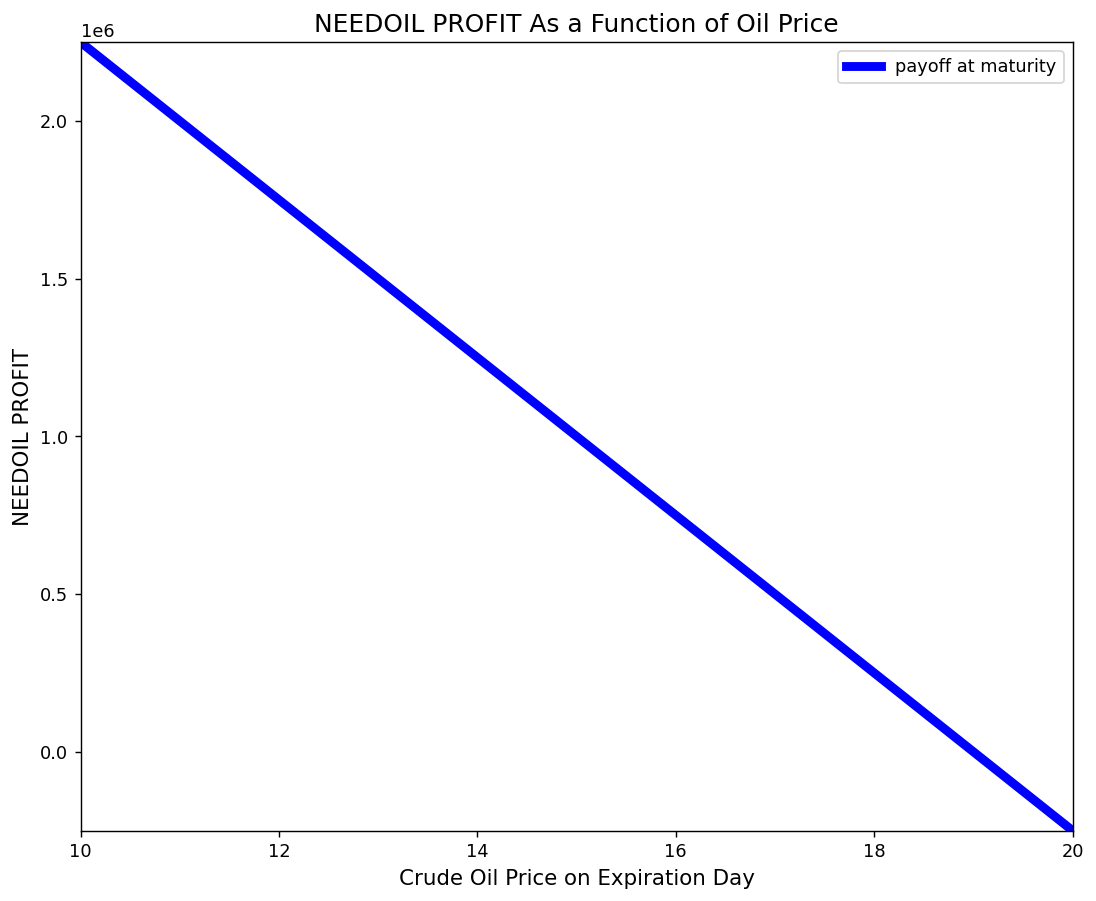

In [1]:
# Needoil payoff without hedging
import numpy as np
import matplotlib.pyplot as plt

PRC = np.linspace(10,20,1000) #oil price
PROFIT = np.zeros((1000,)) # NeedOil payoff

for i in range(len(PRC)):
    PROFIT[i] = -250000*PRC[i]+4750000

fig = plt.figure(dpi=128, figsize=(10,8))
axes = plt.gca()
axes.set_ylim([-250000,2250000])
axes.set_xlim([10,20])
plt.plot(PRC, PROFIT, color='blue', label='payoff at maturity',linewidth = '5')

plt.xlabel('Crude Oil Price on Expiration Day',fontsize=12)
plt.ylabel('NEEDOIL PROFIT',fontsize=12)
plt.title('NEEDOIL PROFIT As a Function of Oil Price',fontsize=14)
plt.legend()
plt.show()


In [1]:
# payoff of long a call
def call(prc):
    return max(prc-15,0)*250000 - 100000
print(call(14))
print(call(15))
print(call(16))

-100000
-100000
150000


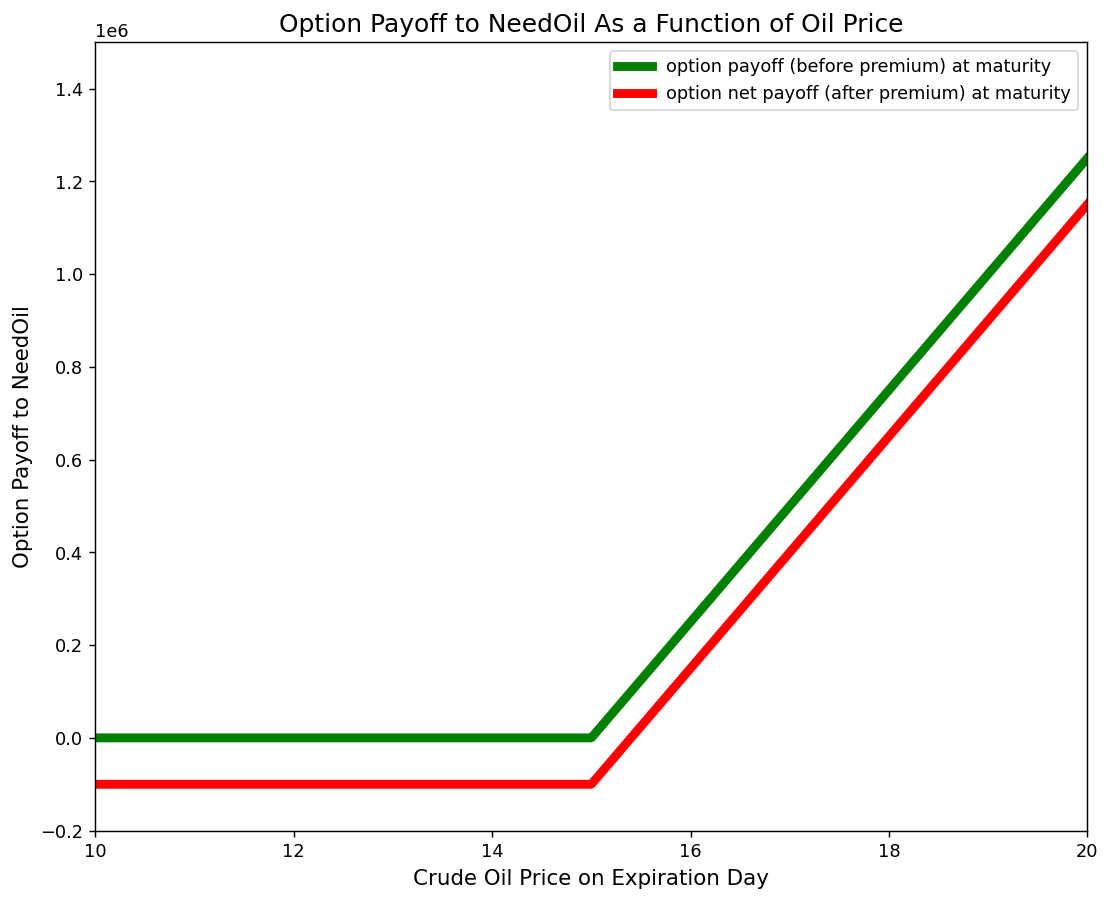

In [2]:
# call option payoff

import numpy as np
import matplotlib.pyplot as plt

call_price = 100000
PRC = np.linspace(10,20,1000) #stock price
X = 15    # exercise price
PAYOFF = np.zeros((1000,)) # call option payoff
PAYOFF_NET = np.zeros((1000,))

for i in range(len(PRC)):
    PAYOFF[i] = (max(PRC[i]-X,0))*250000
    PAYOFF_NET[i] = PAYOFF[i] - call_price

fig = plt.figure(dpi=128, figsize=(10,8))
axes = plt.gca()
axes.set_ylim([-200000,1500000])
axes.set_xlim([10,20])
plt.plot(PRC, PAYOFF, color='green', label='option payoff (before premium) at maturity',linewidth = '5')
plt.plot(PRC, PAYOFF_NET, color='red', label='option net payoff (after premium) at maturity',linewidth = '5')

plt.xlabel('Crude Oil Price on Expiration Day',fontsize=12)
plt.ylabel('Option Payoff to NeedOil',fontsize=12)
plt.title('Option Payoff to NeedOil As a Function of Oil Price',fontsize=14)
plt.legend()
plt.show()


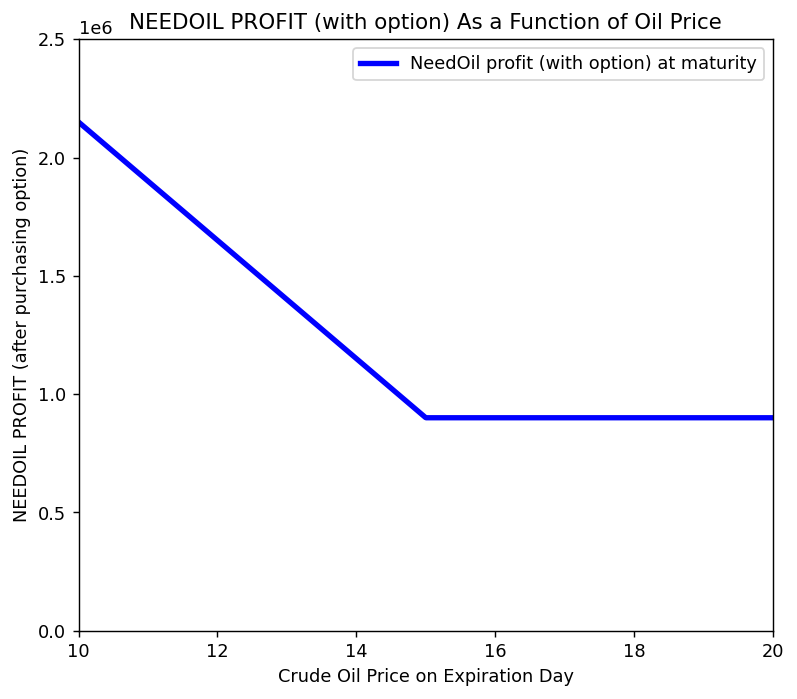

In [3]:
# Needoil payoff after purchasing the call option
import numpy as np
import matplotlib.pyplot as plt

call_price = 100000
X = 15    # exercise price
PRC = np.linspace(10,20,1000) #oil price
PROFIT = np.zeros((1000,)) # NeedOil payoff
PAYOFF_NET = np.zeros((1000,))
PROFIT_CALL = np.zeros((1000,))

for i in range(len(PRC)):
    PROFIT[i] = -250000*PRC[i]+4750000
    PAYOFF_NET[i] = max(PRC[i]-X,0)*250000 - call_price
    PROFIT_CALL[i] = PROFIT[i]+PAYOFF_NET[i]

fig = plt.figure(dpi=128, figsize=(7,6))
axes = plt.gca()
axes.set_ylim([0,2500000])
axes.set_xlim([10,20])
plt.plot(PRC, PROFIT_CALL, color='blue', label='NeedOil profit (with option) at maturity',linewidth = '3')

plt.xlabel('Crude Oil Price on Expiration Day',fontsize=10)
plt.ylabel('NEEDOIL PROFIT (after purchasing option)',fontsize=10)
plt.title('NEEDOIL PROFIT (with option) As a Function of Oil Price',fontsize=12)
plt.legend()
plt.show()


In [4]:
# Net payoff of selling a call
def shortcall(prc):
    return min(15-prc,0)*250000 + 100000
print(shortcall(14))
print(shortcall(15))
print(shortcall(16))

100000
100000
-150000


In [5]:
# payoff to forward buyer
def longforward(prc):
    return 250000*(prc-15)
print(longforward(13))
print(longforward(14))
print(longforward(15))
print(longforward(16))
print(longforward(17))

-500000
-250000
0
250000
500000


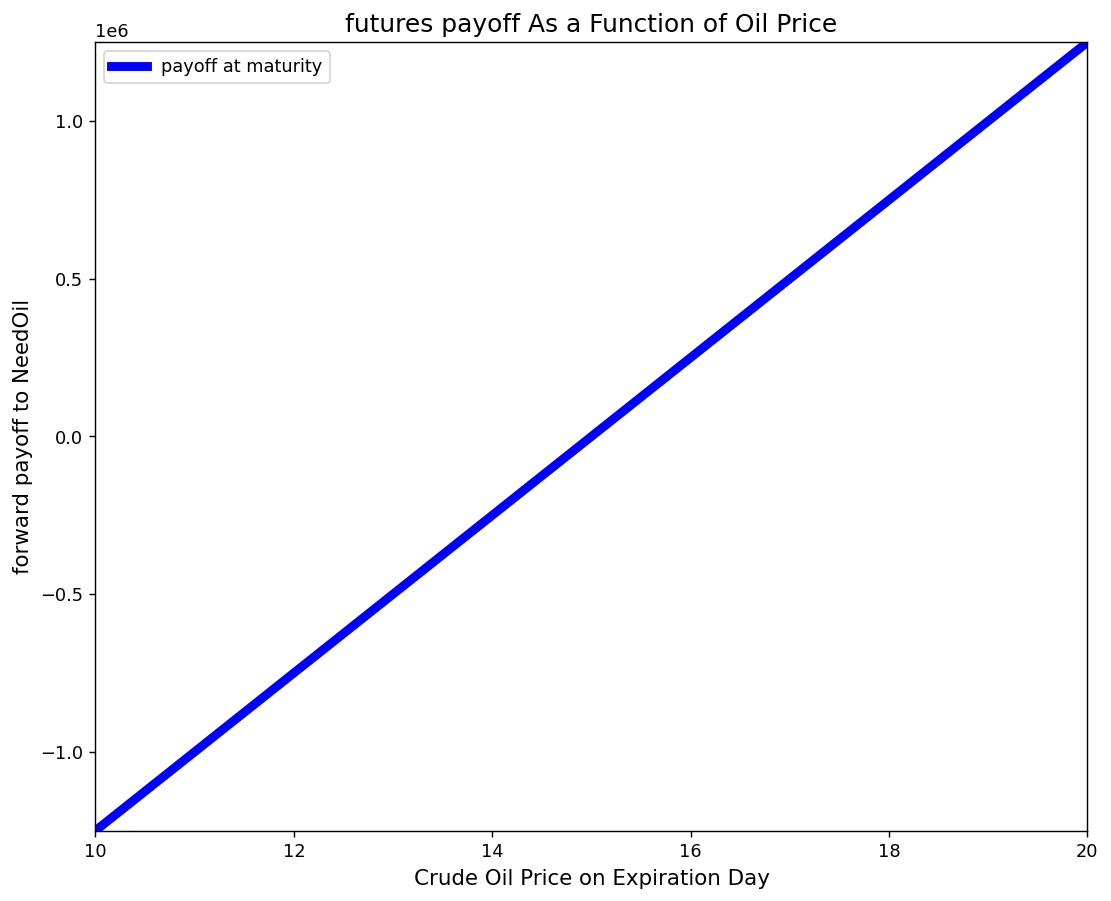

In [6]:
# futures payoff
import numpy as np
import matplotlib.pyplot as plt

prc = np.linspace(10,20,1000) #oil price
payoff = np.zeros((1000,)) # NeedOil payoff

for i in range(len(prc)):
    payoff[i] = 250000*(prc[i]-15)

fig = plt.figure(dpi=128, figsize=(10,8))
axes = plt.gca()
axes.set_ylim([-1250000,1250000])
axes.set_xlim([10,20])
plt.plot(prc, payoff, color='blue', label='payoff at maturity',linewidth = '5')

plt.xlabel('Crude Oil Price on Expiration Day',fontsize=12)
plt.ylabel('forward payoff to NeedOil',fontsize=12)
plt.title('futures payoff As a Function of Oil Price',fontsize=14)
plt.legend()
plt.show()


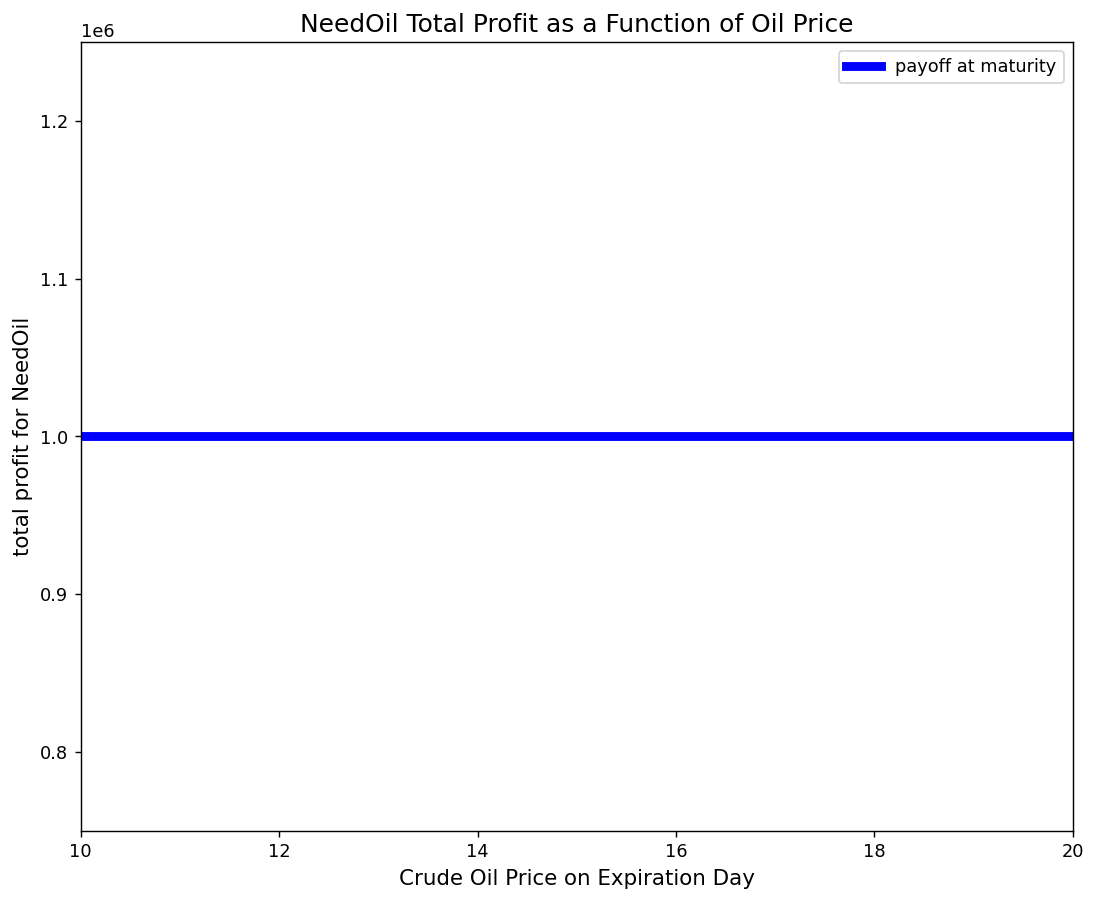

In [9]:
#NeedOil total profit after buying a crude oil forward
import numpy as np
import matplotlib.pyplot as plt

prc = np.linspace(10,20,1000) #oil price
profit = np.zeros((1000,)) # NeedOil profit
payoff = np.zeros((1000,)) # NeedOil payoff
total_profit = np.zeros((1000,)) # aggregate profit to NeedOil after long futures

for i in range(len(prc)):
    profit[i] = -250000*prc[i]+4750000
    payoff[i] = 250000*(prc[i]-15)
    total_profit[i] = profit[i]+payoff[i]

fig = plt.figure(dpi=128, figsize=(10,8))
axes = plt.gca()
axes.set_ylim([750000,1250000])
axes.set_xlim([10,20])
plt.plot(prc, total_profit, color='blue', label='payoff at maturity',linewidth = '5')

plt.xlabel('Crude Oil Price on Expiration Day',fontsize=12)
plt.ylabel('total profit for NeedOil',fontsize=12)
plt.title('NeedOil Total Profit as a Function of Oil Price',fontsize=14)
plt.legend()
plt.show()

In [ ]:
#payoff to Tesla’s covered call
import numpy as np
import matplotlib.pyplot as plt

call_price=100*100
prc = np.linspace(800,1200,1000) #Tesla price
payoff = np.zeros((1000,)) # NeedOil payoff
profit = np.zeros((1000,)) # NeedOil profit
total_profit = np.zeros((1000,)) # aggregate profit to NeedOil after long futures

for i in range(len(prc)):
    profit[i] = 100*prc[i]
    payoff[i] = 100*min(1000-prc[i],0)
    total_profit[i] = profit[i]+payoff[i]+call_price

fig = plt.figure(dpi=128, figsize=(10,8))
axes = plt.gca()
axes.set_ylim([65000,130000])
axes.set_xlim([800,1200])
plt.plot(prc, total_profit, color='blue', label=‘Payoff to covered call',linewidth = '5')
plt.plot(prc, profit, color='red', label=‘Payoff of Tesla stock',linewidth = '5')

plt.xlabel('Tesla Price 6 months later',fontsize=12)
plt.ylabel('Your profit',fontsize=12)
plt.title('Your Profit as a Function of Tesla Price',fontsize=14)
plt.legend()
plt.show()
